# MLP do Zero - Experimentos no MNIST

Este notebook treina a MLP implementada apenas com NumPy, compara duas configuracoes e salva os resultados principais.

In [1]:
from pathlib import Path
import csv
import sys

import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from mlp.network import MLP
from mlp.optimizers import SGD

RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

## Carregamento e pre-processamento

As imagens sao normalizadas para o intervalo `[0, 1]`, achatadas de `28 x 28` para 784 atributos e os rotulos sao convertidos para one-hot encoding. As ultimas 5.000 imagens de treino formam o conjunto de validacao.

In [2]:
(x_train_images, y_train_labels), (x_test_images, y_test_labels) = mnist.load_data()

x_all = x_train_images.reshape(-1, 784).astype(np.float32) / 255.0
x_test = x_test_images.reshape(-1, 784).astype(np.float32) / 255.0
y_all = np.eye(10, dtype=np.float32)[y_train_labels]
y_test = np.eye(10, dtype=np.float32)[y_test_labels]

x_train, x_val = x_all[:-5000], x_all[-5000:]
y_train, y_val = y_all[:-5000], y_all[-5000:]

print("Treino:", x_train.shape, y_train.shape)
print("Validacao:", x_val.shape, y_val.shape)
print("Teste:", x_test.shape, y_test.shape)

Treino: (55000, 784) (55000, 10)
Validacao: (5000, 784) (5000, 10)
Teste: (10000, 784) (10000, 10)


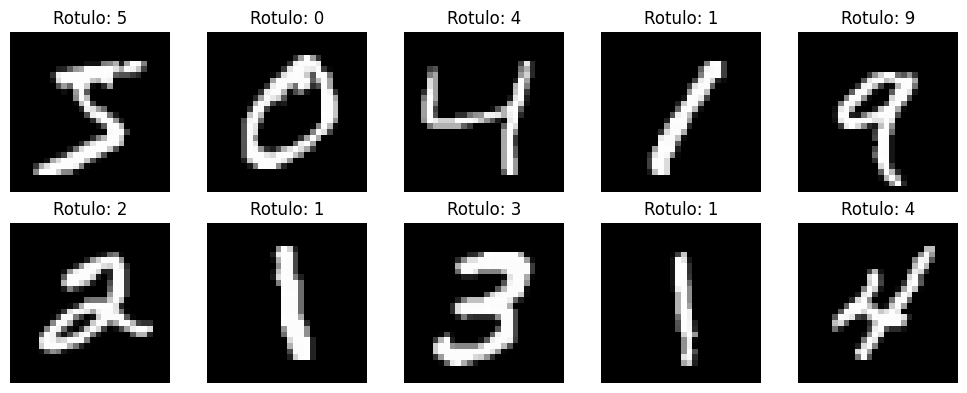

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for index, axis in enumerate(axes.ravel()):
    axis.imshow(x_train_images[index], cmap="gray")
    axis.set_title(f"Rotulo: {y_train_labels[index]}")
    axis.axis("off")
plt.tight_layout()
plt.show()

## Comparacao de configuracoes

As duas redes possuem pelo menos duas camadas ocultas. A principal diferenca esta na quantidade de neuronios e no learning rate.

In [4]:
configurations = [
    {"name": "MLP 128-64", "layers": [784, 128, 64, 10], "learning_rate": 0.10},
    {"name": "MLP 64-32", "layers": [784, 64, 32, 10], "learning_rate": 0.05},
]

experiments = []
for config in configurations:
    print(f"\nTreinando {config['name']}")
    model = MLP(config["layers"], seed=42)
    history = model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=128,
        optimizer=SGD(config["learning_rate"]),
        validation_data=(x_val, y_val),
        seed=42,
    )
    test_metrics = model.evaluate(x_test, y_test)
    experiments.append({"config": config, "model": model, "history": history, "test": test_metrics})
    print("Teste:", test_metrics)


Treinando MLP 128-64


Epoch 1/5 - loss: 0.2571 - accuracy: 0.9237 - val_loss: 0.2026 - val_accuracy: 0.9430


Epoch 2/5 - loss: 0.1651 - accuracy: 0.9530 - val_loss: 0.1374 - val_accuracy: 0.9610


Epoch 3/5 - loss: 0.1406 - accuracy: 0.9585 - val_loss: 0.1235 - val_accuracy: 0.9660


Epoch 4/5 - loss: 0.1112 - accuracy: 0.9672 - val_loss: 0.1103 - val_accuracy: 0.9678


...

Epoch 1/5 - loss: 0.3412 - accuracy: 0.9030 - val_loss: 0.2627 - val_accuracy: 0.9256


Epoch 2/5 - loss: 0.2509 - accuracy: 0.9282 - val_loss: 0.1950 - val_accuracy: 0.9456


Epoch 3/5 - loss: 0.2213 - accuracy: 0.9352 - val_loss: 0.1753 - val_accuracy: 0.9520


Epoch 4/5 - loss: 0.1926 - accuracy: 0.9434 - val_loss: 0.1567 - val_accuracy: 0.9556


Epoch 5/5 - loss: 0.1805 - accuracy: 0.9467 - val_loss: 0.1520 - val_accuracy: 0.9568
Teste: {'loss': np.float64(0.18683290107716707), 'accuracy': np.float64(0.9454)}


## Curvas e tabela comparativa

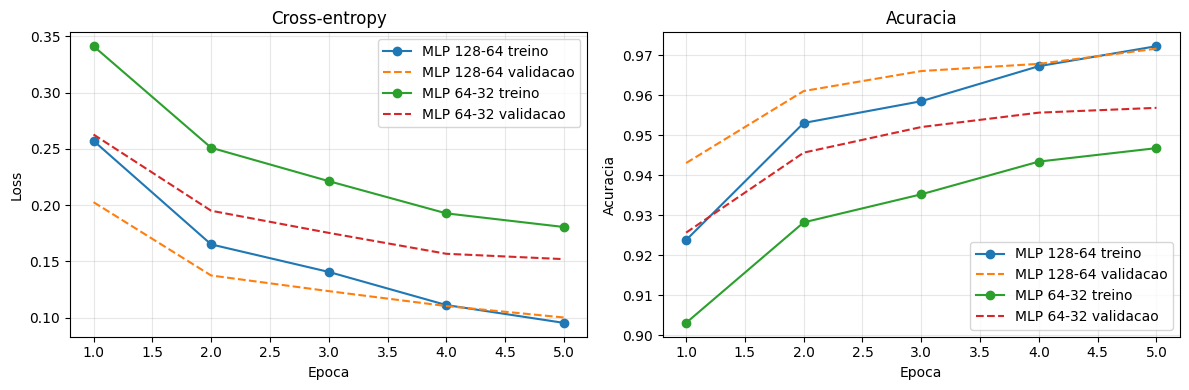

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for experiment in experiments:
    name = experiment["config"]["name"]
    history = experiment["history"]
    epochs = range(1, len(history["loss"]) + 1)
    axes[0].plot(epochs, history["loss"], marker="o", label=f"{name} treino")
    axes[0].plot(epochs, history["val_loss"], linestyle="--", label=f"{name} validacao")
    axes[1].plot(epochs, history["accuracy"], marker="o", label=f"{name} treino")
    axes[1].plot(epochs, history["val_accuracy"], linestyle="--", label=f"{name} validacao")

axes[0].set(title="Cross-entropy", xlabel="Epoca", ylabel="Loss")
axes[1].set(title="Acuracia", xlabel="Epoca", ylabel="Acuracia")
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
comparison_rows = []
for experiment in experiments:
    config = experiment["config"]
    row = {
        "configuracao": config["name"],
        "arquitetura": "-".join(map(str, config["layers"])),
        "learning_rate": config["learning_rate"],
        "val_accuracy": experiment["history"]["val_accuracy"][-1],
        "test_accuracy": experiment["test"]["accuracy"],
        "test_loss": experiment["test"]["loss"],
    }
    comparison_rows.append(row)
    print(row)

with open(RESULTS_DIR / "comparison.csv", "w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=comparison_rows[0].keys())
    writer.writeheader()
    writer.writerows(comparison_rows)

{'configuracao': 'MLP 128-64', 'arquitetura': '784-128-64-10', 'learning_rate': 0.1, 'val_accuracy': np.float64(0.9716), 'test_accuracy': np.float64(0.9667), 'test_loss': np.float64(0.1085766201115013)}
{'configuracao': 'MLP 64-32', 'arquitetura': '784-64-32-10', 'learning_rate': 0.05, 'val_accuracy': np.float64(0.9568), 'test_accuracy': np.float64(0.9454), 'test_loss': np.float64(0.18683290107716707)}


## Matriz de confusao do melhor modelo

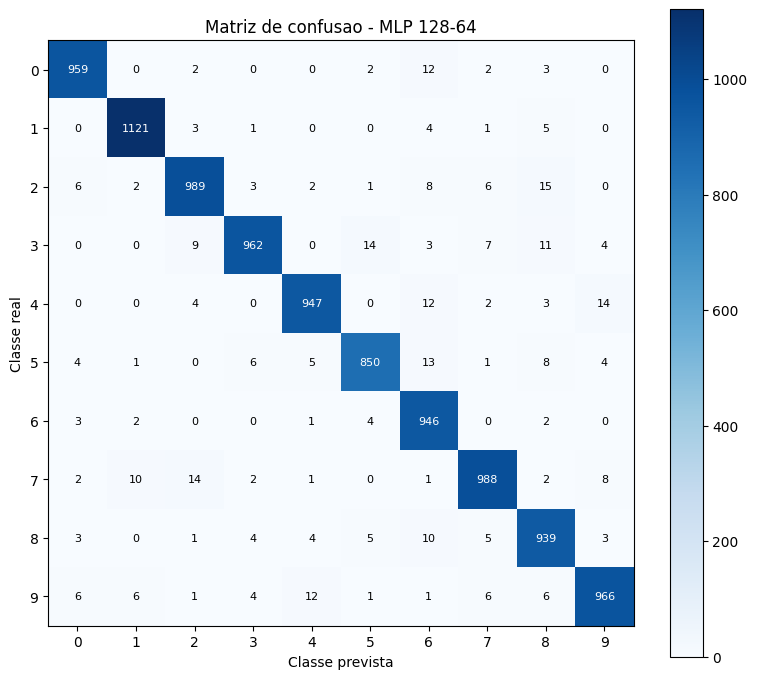

In [7]:
best_experiment = max(experiments, key=lambda item: item["history"]["val_accuracy"][-1])
best_model = best_experiment["model"]
test_predictions = best_model.predict(x_test)

confusion_matrix = np.zeros((10, 10), dtype=int)
np.add.at(confusion_matrix, (y_test_labels, test_predictions), 1)

plt.figure(figsize=(8, 7))
plt.imshow(confusion_matrix, cmap="Blues")
plt.title(f"Matriz de confusao - {best_experiment['config']['name']}")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.xticks(range(10))
plt.yticks(range(10))
plt.colorbar()
for row in range(10):
    for column in range(10):
        color = "white" if confusion_matrix[row, column] > confusion_matrix.max() / 2 else "black"
        plt.text(column, row, confusion_matrix[row, column], ha="center", va="center", color=color, fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

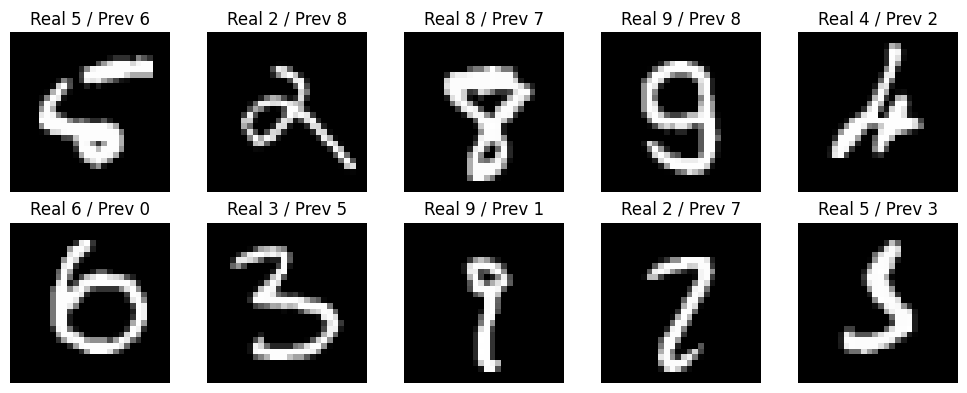

In [8]:
incorrect = np.flatnonzero(test_predictions != y_test_labels)[:10]
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for sample_index, axis in zip(incorrect, axes.ravel()):
    axis.imshow(x_test_images[sample_index], cmap="gray")
    axis.set_title(f"Real {y_test_labels[sample_index]} / Prev {test_predictions[sample_index]}")
    axis.axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "classification_errors.png", dpi=150, bbox_inches="tight")
plt.show()

## Analise

Depois de executar o notebook, descreva aqui por que uma configuracao foi melhor que a outra, quais digitos foram mais confundidos e o que voce aprendeu durante os experimentos.